# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [325]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'cmemery2'  # <-- set this
d = np.genfromtxt(f'../../labs/03/data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.42 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

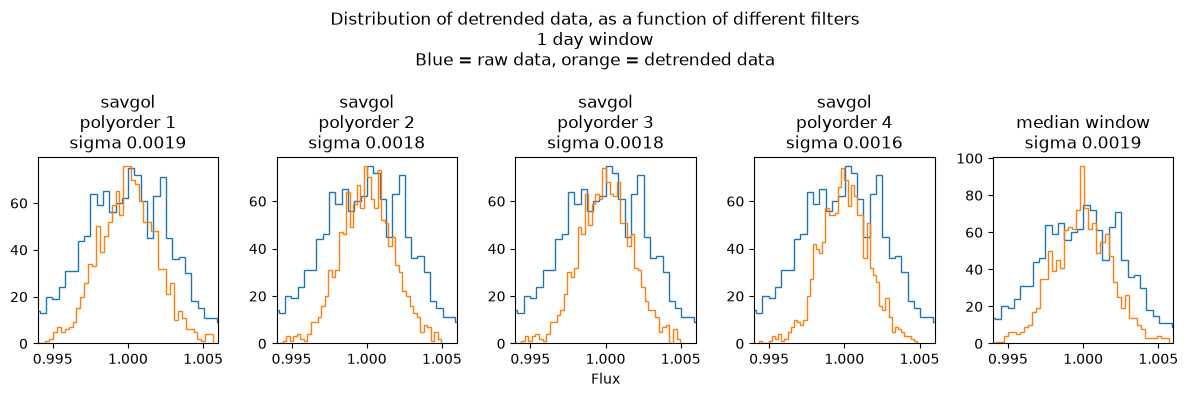

In [326]:
# Part 1: your work here
# alert ephemeris (community pipeline, approximate): P_alert = 8.79 d, t0_alert = 7.1 d
# Taken from the csv. I literally cannot see ANYTHING
P_alert = 8.79
# P_alert =  3.80
t0_alert = 7.1


from scipy.ndimage import median_filter
from scipy.signal import savgol_filter
from scipy.fft import fft, ifft, fftfreq

cadence = np.median(np.diff(t))
window = max(3, int(round((24 / 24.) / cadence)))
trend = median_filter(flux, size=window)
flux_detrended = flux - trend + 1.0

cadence = np.median(np.diff(t))
window = max(3, int(round((24 / 24.) / cadence)))
if window % 2 == 0:
    window += 1

fig2, ax2 = plt.subplots(1, 5, figsize=(12, 4))
for polyorder in range(4):
    trend = savgol_filter(flux, window, polyorder+1)
    flux_detrended2 = flux / trend

    ax2[polyorder].hist(flux, bins=50, histtype='step')
    n, bins, _ = ax2[polyorder].hist(flux_detrended2, bins=50, histtype='step')
    ax2[polyorder].set_xlim(0.994, 1.006)
    ax2[polyorder].set_title(f"savgol\npolyorder {polyorder+1}\nsigma {np.std(flux_detrended2):.2g}")
ax2[4].hist(flux, bins=50,histtype='step')
n, bins, _ = ax2[4].hist(flux_detrended, bins=50,histtype='step')
ax2[4].set_xlim(0.994, 1.006)
ax2[4].set_title(f"median window\nsigma {np.std(flux_detrended):.2g}")
ax2[2].set_xlabel('Flux')

plt.suptitle("Distribution of detrended data, as a function of different filters\n1 day window\nBlue = raw data, orange = detrended data")
plt.tight_layout()
plt.show()

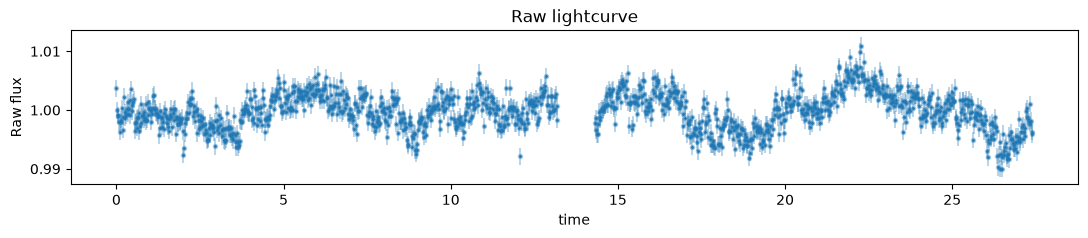

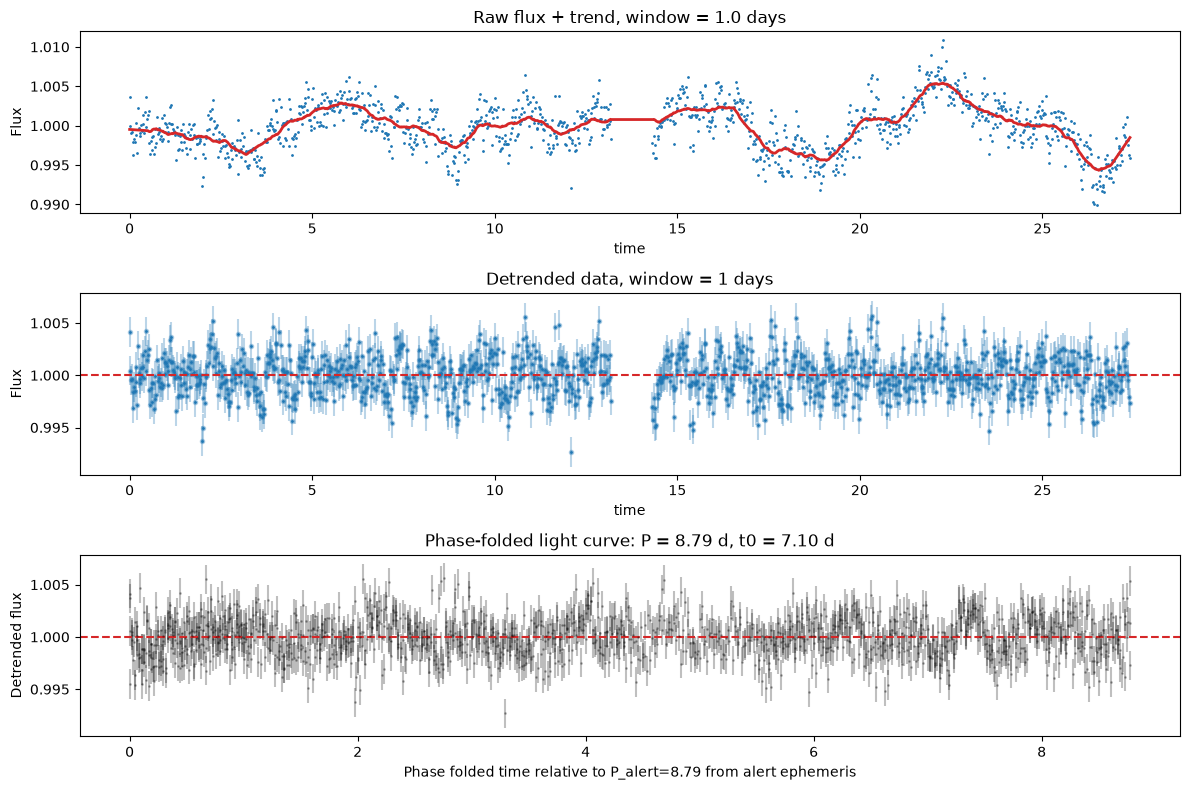

In [398]:
# raw flux
fig, ax = plt.subplots(figsize=(13, 2))
ax.plot(t, flux,'.',ms=2,color='tab:blue')
ax.errorbar(t, flux,yerr=sigma,fmt='.',zorder=-1,alpha=.3,color='tab:blue')
ax.set_xlabel("time")
ax.set_ylabel("Raw flux")
ax.set_title("Raw lightcurve")
plt.show()

# try different windows because WHERE IS IT!!!!!!!!! WHERE IS IT!!!!!!!!!
cadence = 30./60/24
# window_lengths = [0.5, 1, 1.5, 2]
window_lengths = [1]
for i, window_length in enumerate(window_lengths):
    fig, ax = plt.subplots(3, 1,figsize=(12, 8))
    i=0
    i1 = i * 3 + 0
    i2 = i * 3 + 1
    i3 = i * 3 + 2
    window = int(round(window_length / cadence))
    #Savitzky-Golay requires an odd window.
    if window % 2 == 0:
        window += 1
    trend = savgol_filter(flux,window_length=window,polyorder=1)
    # trend = median_filter(flux, size=window)
    flux_detrended = flux / trend
    sigma_detrended = sigma / trend

    # Trend
    ax[i1].plot(t, flux,'.',ms=2,color='tab:blue')
    ax[i1].plot(t, trend,color='tab:red',lw=2,)
    ax[i1].set_xlabel("time")
    ax[i1].set_ylabel("Flux")
    ax[i1].set_title(f"Raw flux + trend, window = {window/48:.1f} days")

    # Detrended
    ax[i2].plot(t,flux_detrended,'.',ms=2,color='tab:blue')
    ax[i2].errorbar(t,flux_detrended,yerr=sigma_detrended,fmt='.',zorder=-1,alpha=.3,color='tab:blue')
    ax[i2].axhline(1,color='tab:red',ls='--')
    ax[i2].set_xlabel("time")
    ax[i2].set_ylabel("Flux")
    ax[i2].set_title(f"Detrended data, window = {window_length} days")

    ax[i3].errorbar(t%P_alert,flux_detrended,yerr=sigma_detrended,fmt='.',ms=2,alpha=0.25,color='black')
    ax[i3].axhline(1.0, color='tab:red', ls='--')

    ax[i3].set_xlabel("Phase folded time relative to P_alert=8.79 from alert ephemeris")
    ax[i3].set_ylabel("Detrended flux")
    ax[i3].set_title(
    f"Phase-folded light curve: P = {P_alert:.2f} d, "
    f"t0 = {t0_alert:.2f} d")

    plt.tight_layout()
    plt.show()

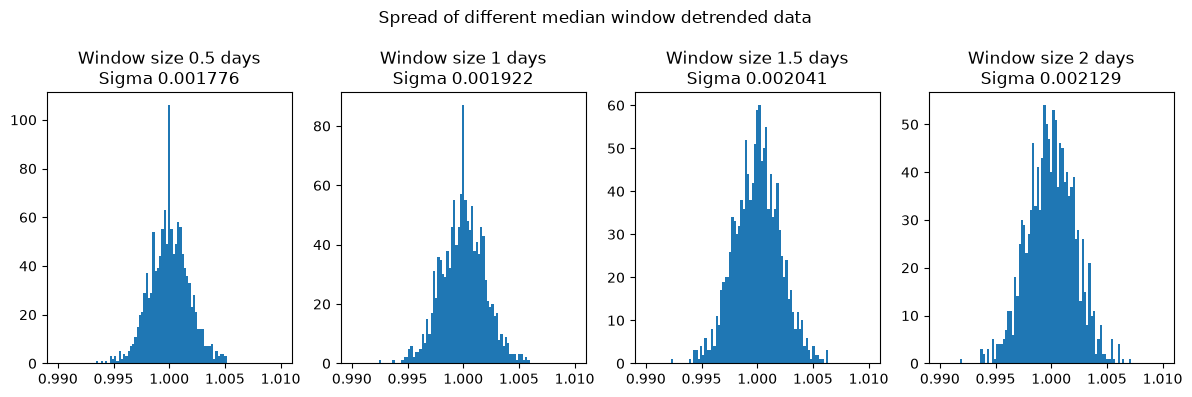

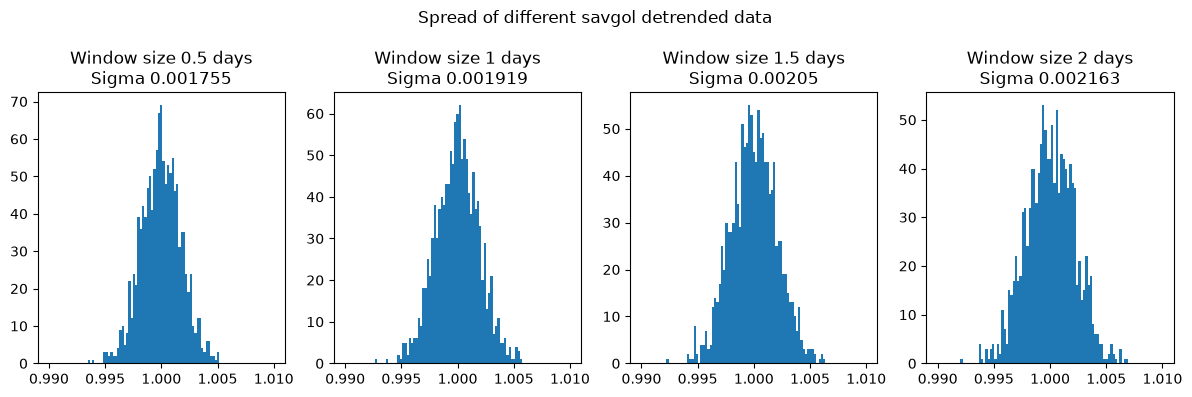

Actual measurement data sigma = 0.001415


In [330]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
bins = np.linspace(0.99, 1.01, 100)
for i, window_length in enumerate(window_lengths):
    window = int(round(window_length / cadence))
    if window % 2 == 0:
        window += 1
    trend = median_filter(flux, size=window)
    flux_detrended = flux /trend
    sigma_detrended = sigma/trend

    n, bins, _ = ax[i].hist(flux_detrended, bins=bins)
    ax[i].set_title(f'Window size {window_length} days\n'+
                    f'Sigma {np.std(flux_detrended):.4g}')

fig.suptitle('Spread of different median window detrended data')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(12, 4))
bins = np.linspace(0.99, 1.01, 100)
for i, window_length in enumerate(window_lengths):
    window = int(round(window_length / cadence))
    if window % 2 == 0:
        window += 1
    trend = savgol_filter(flux,window_length=window,polyorder=1)
    flux_detrended = flux /trend 
    sigma_detrended = sigma/trend

    n, bins, _ = ax[i].hist(flux_detrended, bins=bins)
    ax[i].set_title(f'Window size {window_length} days\n'+
                    f'Sigma {np.std(flux_detrended):.4g}')

fig.suptitle('Spread of different savgol detrended data')
plt.tight_layout()
plt.show()

print(f'Actual measurement data sigma = {sigma[0]}')

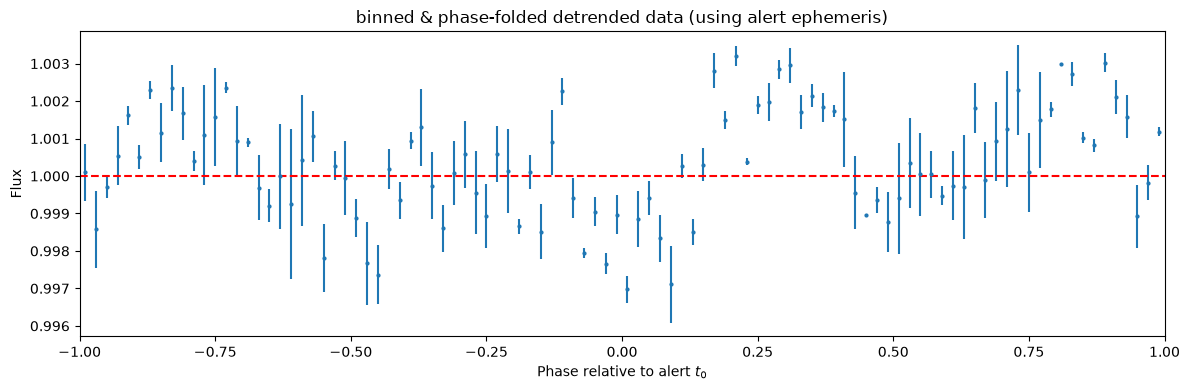

In [331]:
# Do actual phase folding using the alert ephemeris
P_alert = 8.79
t0_alert = 7.1

phase = ((t - t0_alert + 0.5*P_alert) % P_alert) - 0.5*P_alert

# +/- 1 day snapshot around assumed transit
sel = np.abs(phase) < 1

phase_bins = np.linspace(-1, 1, 101)
phase_centers = 0.5 * (phase_bins[:-1] + phase_bins[1:])
binned_flux = np.full(len(phase_centers), np.nan)
binned_err = np.full(len(phase_centers), np.nan)

for i in range(len(phase_centers)):
    m = ((phase[sel] >= phase_bins[i]) &(phase[sel] < phase_bins[i+1]))
    y = flux_detrended[sel][m]
    if len(y) > 0:
        binned_flux[i] = np.mean(y)
        binned_err[i] = np.std(y) / np.sqrt(len(y))

fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(phase_centers,binned_flux,yerr=binned_err,fmt='o',ms=2)
ax.axhline(1, color='red', ls='--')
ax.set_xlim(-1, 1)
ax.set_xlabel("Phase relative to alert $t_0$")
ax.set_ylabel("Flux")
ax.set_title("binned & phase-folded detrended data (using alert ephemeris)")

plt.tight_layout()
plt.show()


In [ ]:
#....the pipeline reported transit from the csv doesn't look like anything at all

**ANSWERS (initial guesses + scatter check):**

### the trend

The raw lightcurve shows variability on the timescales of days, which i choose to believe is the instrumental / systematic error and not transits, since it doesn't look like a transit shape at all. I can't actually find any individual transit events, probably because the expected depth is smaller or comparable to the point to point scatter, despite testing phase folding different periods. Am i being punished? Is there actually a transit here or am I hallucinating?

### detrending nightmare nightmare nightmare

Filter choices: I detrended with a median window filter & a 2nd order polynomial savitzky golay filter, after being advised to do so by a friend who does transit research. The AltaiPony package technically uses a spline then two savgol filters, and the lightkurve package also kind of has savgol, so i was kind of biased into thinking it's trustworthy as it's something of a transit research standard i guess. Savgol filter kind of sucks for the edges of the data, like at the beginning/gap in the middle/end, since it's fitting the data to a polynomial and setting the trend at each point to the value of the polynomial there. And there's a cutoff of data to fit a polynomial to. 

Savgol polynomial order: I tried a bunch of different polynomial orders for the savgol since I wanted to check how much each would smooth the data; i ended up choosing 2nd order polynomial since higher orders i was concerned it was going to overfit the data & 2nd order polynomial generated more gaussian noise in the data than 1st order. 

Median filter is better than savgol i guess: Although the savgol trends seem to be smoother than the median filter, therefore hypothetically removing less of the transit signal, I noticed that savgol seemed to change the transit shape more than the median filter did when I tested on other students' data. Other students have extremely obvious transits post-detrending, but while median filter retained the transit-y shape, the savgol filter pushed the transit shape 'upward', ie. immediately prior to and after the transit the flux seemed to rise up from flux=1 a little. I thought this might be bad for trying to fit for the transit trapezoid shape.

Smoothing scale: I tested windows of 12hr, 1day, 1.5day, 2days. I checked the other students' data and found for many of them that their transits had like a period of like ~3hr (also their transits are SUPER VISIBLE. so WHERE IS MY TRANSIT??), after which I decided to be super conservative and test large windows as to not accidentally flatten my transit, on the order of a few hours, into dust.

Conclusion: I think i'm going to keep the 1 day median filter smoothing, since I can kind of see the histogram has a bump at flux=~0.9975 that might be signal.

### initial guesses

I can't see literally anything, so I'm just going to use the info given in the csv: 

alert ephemeris (community pipeline, approximate): P_alert = 8.79 d, t0_alert = 7.1 d

Because i can't distinguish anything by eye, i can't guess depth or duration very well at all, and just do depth = .1% and duration ~ 6hr as starting values. For baseline flux, just F0 = 1.

$\theta = (t_0, P, \delta, T, F_0) = (7.1, 8.79, 0.001, 6\text{hr}, 1)$

### out of transit scatter

For each window size savgol filter  of .5, 1, 1.5, and 2 days, i got data sigmas of .0018, .0019, .002, and .0022. For the median filters, 0018, .0019, .002, and .0021. The actual measurement sigma is .0014. So since the lightcurve noise is greater than each data point measurement noise, there is very obviously noise that is not being accounted for by measurement error.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

Optimization terminated successfully.

Best-fit model
t0       = 7.009835 d
P        = 3.424972 d
depth    = 0.00148777
duration = 0.305221 days = 7.325 hr
F0       = 1.00007095


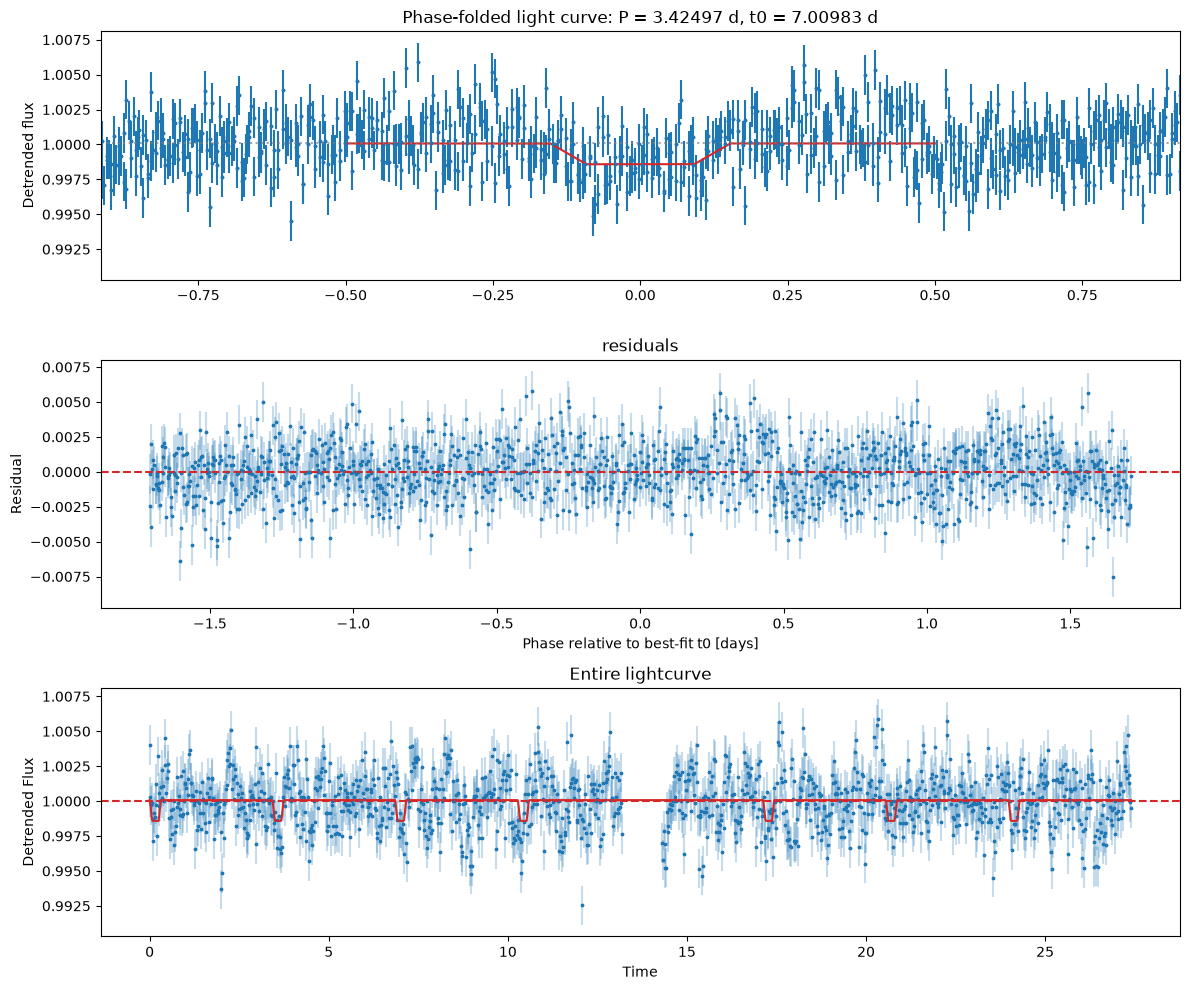

chi^2       = 2251.23
dof         = 1258
chi^2 / dof = 1.790


In [439]:
window_length = 1
window = int(round(window_length / cadence))
if window % 2 == 0:
    window += 1
trend = median_filter(flux,size=window,)
flux_detrended = flux /trend 
sigma_detrended = sigma/trend

def neg2logL(theta):
    t0, period, depth, duration, baseline = theta
    model = transit_model(t, t0, period, depth, duration, baseline)
    resid = flux_detrended - model
    return np.sum(resid**2 / sigma_detrended**2 + np.log(sigma_detrended**2))
def fit_transit(x0):
    return minimize(neg2logL, x0=x0, method='Nelder-Mead', 
                    options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 5000})
    
x0 = np.array([7.1, 8.79, 0.001, 0.25, 1.0])
x0 = np.array([7.1, 1.709070907090709*2, 0.001, 0.25, 1.0])
res = fit_transit(x0)
t0_fit, P_fit, depth_fit, T_fit, F0_fit = res.x

print(res.message)
print()
print("Best-fit model")
print(f"t0       = {t0_fit:.6f} d"+
      f"\nP        = {P_fit:.6f} d"+
      f"\ndepth    = {depth_fit:.8f}"+
      f"\nduration = {T_fit:.6f} days = {T_fit*24:.3f} hr"+
      f"\nF0       = {F0_fit:.8f}")

model_fit = transit_model(t, t0_fit, P_fit, depth_fit, T_fit, F0_fit)
residuals = flux_detrended - model_fit

phase = ((t - t0_fit + 0.5 * P_fit) % P_fit) - 0.5 * P_fit
phase_grid = np.linspace(-0.5, 0.5, 2000)
model_phase = transit_model(t0_fit + phase_grid, t0_fit, P_fit, depth_fit, T_fit, F0_fit)
model_phase2 = transit_model(t, t0_fit, P_fit, depth_fit, T_fit, F0_fit)


fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].errorbar(phase, flux_detrended, yerr=sigma_detrended, fmt='.', ms=3)
ax[0].scatter(phase, flux_detrended, s=3)
ax[0].plot(phase_grid, model_phase, color='tab:red')
ax[0].axhline(F0_fit, color='gray', ls=':', alpha=0.7)
ax[0].set_ylabel("Detrended flux")
ax[0].set_title(f"Phase-folded light curve: P = {P_fit:.5f} d, t0 = {t0_fit:.5f} d")

ax[1].errorbar(phase, residuals, yerr=sigma_detrended, fmt='.', ms=2, alpha=.25)
ax[1].scatter(phase, residuals, s=3)
ax[1].axhline(0, color='tab:red', ls='--')
ax[1].set_xlabel("Phase relative to best-fit t0 [days]")
ax[1].set_ylabel("Residual")
ax[1].set_title("residuals")

ax[2].errorbar(t, flux_detrended, yerr=sigma_detrended, fmt='.', ms=2, alpha=.25)
ax[2].scatter(t, flux_detrended, s=3)
ax[2].plot(t, model_phase2, color='tab:red')
ax[2].axhline(1, color='tab:red', ls='--')
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Detrended Flux")
ax[2].set_title("Entire lightcurve")

zoom = max(0.5, 3 * T_fit)
ax[0].set_xlim(-zoom, zoom)

plt.tight_layout()
plt.show()



chi2 = np.sum(residuals**2 / sigma_detrended**2)
dof = len(t) - len(res.x)
print(f"chi^2       = {chi2:.2f}")
print(f"dof         = {dof}")
print(f"chi^2 / dof = {chi2/dof:.3f}")

In [376]:
res_half = fit_transit(np.array([7.1, 8.79/2, 0.001, 0.25, 1.0]))
res_full = fit_transit(np.array([7.1, 8.79, 0.001, 0.25, 1.0]))

print("P ~ 4.4:", res_half.fun)
print("P ~ 8.8:", res_full.fun)

P ~ 4.4: -14267.603795744002
P ~ 8.8: -14277.278882957911


In [ ]:
rng = np.random.default_rng(72735)
n_boot = 1000
model_fit = transit_model(t, t0_fit, P_fit, depth_fit, T_fit, F0_fit)
residuals = flux_detrended - model_fit

def fit_bootstrap_dataset(y_boot, x0=res.x):
    def neg2logL_boot(theta):
        t0, period, depth, duration, baseline = theta
        model = transit_model(t, t0, period, depth, duration, baseline)
        resid = y_boot - model #instead of neg2logL which has flux_detrended, use y_boot
        return np.sum(resid**2 / sigma_detrended**2 + np.log(sigma_detrended**2))
    return minimize(neg2logL_boot, x0=x0, method='Nelder-Mead', 
                   options={'xatol': 1e-7, 'fatol': 1e-7, 'maxiter': 3000})
point_samples = []
for k in range(n_boot):
    # resample individual residuals
    boot_resid = rng.choice(residuals,size=len(residuals),replace=True)
    y_boot = model_fit + boot_resid
    fit = fit_bootstrap_dataset(y_boot)
    if fit.success:
        point_samples.append(fit.x)
point_samples = np.asarray(point_samples)
print(f"Successful point-bootstrap fits: {len(point_samples)}/{n_boot}")


# Block bootstrap
block_length = 48
print(f"Block length = {block_length} points")
print(f"Block duration = {block_length * cadence:.3f} days")
#make sure all the blocks are the same size
blocks = [residuals[i:i + block_length] for i in range(len(residuals) - block_length + 1)]
n_blocks = len(blocks)

print(f"Number of blocks = {n_blocks}")

block_samples = []

for k in range(n_boot):
    boot_resid = np.concatenate([blocks[i] for i in rng.integers(0, n_blocks, size=n_blocks + 1)])
    boot_resid = boot_resid[:len(residuals)]
    y_boot = model_fit + boot_resid
    fit = fit_bootstrap_dataset(y_boot)
    if fit.success:
        block_samples.append(fit.x)

block_samples = np.asarray(block_samples)

print(f"Successful block-bootstrap fits: {len(block_samples)}/{n_boot}")

Successful point-bootstrap fits: 1000/1000
Block length = 48 points
Block duration = 1.000 days
Number of blocks = 1216
Successful block-bootstrap fits: 1000/1000



Hessian err:
t0 [days]            = 7.1079931 +/- 0.00248
P [days]             = 8.7951801 +/- 0.00541
depth                = 0.0015807432 +/- 0.000271
duration [days]      = 0.26502308 +/- 0.00453
F0                   = 1.000013 +/- 4.04e-05

Point-wise bootstrap:
t0 [days]            = 7.1075635 +/- 0.0433
P [days]             = 8.7961103 +/- 0.0486
depth                = 0.0017342706 +/- 0.000357
duration [days]      = 0.26216214 +/- 0.0397
F0                   = 1.0000142 +/- 5.34e-05

1 day block bootstrap:
t0 [days]            = 7.1079625 +/- 0.129
P [days]             = 8.8021762 +/- 0.148
depth                = 0.0019656767 +/- 0.000546
duration [days]      = 0.26247151 +/- 0.0627
F0                   = 1.0000087 +/- 6.69e-05


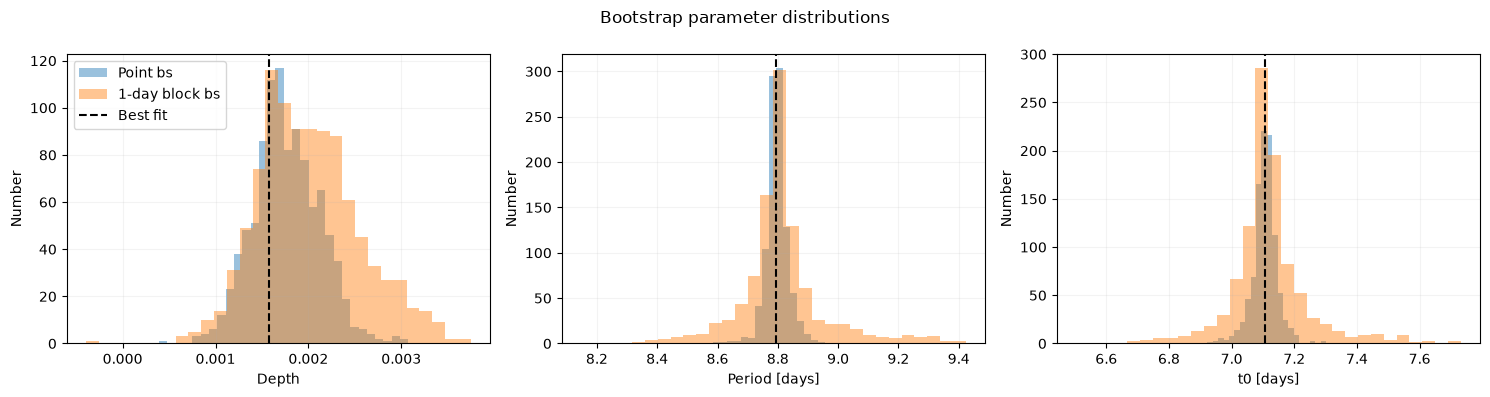

In [400]:
labels = ["t0 [days]", "P [days]", "depth", "duration [days]", "F0"]



# curvature (Hessian) by finite differences, for the error bars
h = 1e-4
n = len(res.x)
hess = np.zeros((n, n))
f0 = neg2logL(res.x)
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h; ej[j] = h
        hess[i, j] = (neg2logL(res.x + ei + ej) - neg2logL(res.x + ei - ej)
                        - neg2logL(res.x - ei + ej) + neg2logL(res.x - ei - ej)) / (4 * h**2)
cov = 2 * np.linalg.inv(hess)   # factor of 2: -2lnL is chi^2, not -lnL
errs = np.sqrt(np.diag(cov))
print("\nHessian err:")
for label, value, error in zip(labels, res.x, errs):
    print(f"{label:20s} = {value:.8g} +/- {error:.3g}")

print("\nPoint-wise bootstrap:")
for i, label in enumerate(labels):
    print(f"{label:20s} = {np.median(point_samples, axis=0)[i]:.8g} +/- {np.std(point_samples, axis=0)[i]:.3g}")
print("\n1 day block bootstrap:")
for i, label in enumerate(labels):
    print(f"{label:20s} = {np.median(block_samples, axis=0)[i]:.8g} +/- {np.std(block_samples, axis=0)[i]:.3g}")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

parameter_info = [(2, "Depth"),(1, "Period [days]"),(0, "t0 [days]")]
for ax, (idx, xlabel) in zip(axes, parameter_info):

    ax.hist(point_samples[:, idx],bins=30,alpha=0.45,label='Point bs')
    ax.hist(block_samples[:, idx],bins=30,alpha=0.45,label='1-day block bs')
    ax.axvline(res.x[idx],color='black',ls='--',label='Best fit')

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number")
    ax.grid(alpha=0.15)

axes[0].legend(loc='upper left')

plt.suptitle("Bootstrap parameter distributions")
plt.tight_layout()
plt.show()

In [397]:
bin_length = int(round(5.0 / 24.0 / cadence))
n_bins = len(residuals) // bin_length
binned_residuals = np.zeros(n_bins)
for i in range(n_bins):
  binned_residuals[i] = np.mean(residuals[bin_length*i:bin_length*(i+1)])

print(f"sigma_individual = {np.std(residuals):.6g}")
print(f"predicted sigma_5 hr bins, if independent \n = sigma_individual/sqrt(pts per bin) = {np.std(residuals)/np.sqrt(bin_length):.6g}")
print(f"actual sigma_5 hr binned = {np.std(binned_residuals):.6g}")

sigma_individual = 0.00190791
predicted sigma_5 hr bins, if independent 
 = sigma_individual/sqrt(pts per bin) = 0.000603333
actual sigma_5 hr binned = 0.00104613


**FINAL ANSWER:** $\delta = $ 1.58 $\pm$ .546 ppt, $P = $ 8.80 $\pm$ .148 d, $t_0 = $ 7.108 $\pm$ .129 d

**Which uncertainty and why (a short paragraph):**


The hessian & pointwise bootstrap assume the noise is independent from point to point since you resample random points, but the block bootstrap assumes the residuals are time correlated, since you resample chunks of continuous data. The residuals in reality dont have fully independent noise, but have time correlated noise, which we only partially could correct for by detrending the data.

The hessian uncertainty is smallest since it's based on independent point to point measurement uncertainty. In part 1, the scatter of the detrended light curve was larger than the point measurement uncertainty. Therefore, the hessian will underestimate uncertainty, since it incorporates these measurement errors & assumes they describe the noise. The pointwise bootstrap has slightly larger uncertainty since the random sampling of points lets it examine the larger residual scatter better, but this still assumes the residuals are independent. The block bootstrap is the largest, since it has a low number of samples that it randomly selects & the correlated noise will make the fits more uncertain. Since the sigma of the 5 hr binned detrended lightcurve is much greater than the sigma of the lightcurve / sqrt(pts per bin) isntead of equal to it, that means that the noise is not independent from point to point

i adopted the block bootstrap uncertainty since it doesn't assume residuals are independent from point to point


HOWEVER, i'm very inclined to say that the data gives a very weak evidence for the transit, since the transit still very much looks like noise. For example, the SNR = 1.58/.546 = 2.893772894 $\sigma$ for transit depth. That's very small! I try to justify that this transit is actually signal in part 4

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:*
It uses a detrending algorithm with a 6 hour window. The transit that i found was 6.4hr; this window is on a timescale comparable to the signal. Since it got a depth of 2.175ppt, and i got 1.581ppt with my 1 day detrending, this difference means the transit we fit for has a different shape.

In [440]:
# Part 3: demonstrations here
x0 = np.array([7.1, 1.709070907090709*2, 0.001, 0.25, 1.0])
res = fit_transit(x0)

my_fit_param = res.x
bad_fit_param = [7.52665873e+00, 8.81709466e+00, 2.17541245e-03, 8.88785699e-02, 9.99830310e-01]

print(my_fit_param)

[7.00983459e+00 3.42497242e+00 1.48777117e-03 3.05220501e-01
 1.00007095e+00]


The correct treatment is to use a smoothing scale that's much longer than the transit, check to make sure that your transit is not just noise. From the plot, it really looks like it's just noise.


*Flaw 2:*
It uses np.std(flux_detrended) as the uncertainty of every observation, and doesn't notice that the datapoints have per point measurement error uncertainty. So this means a difference of 1.4 ppt from measurement error and 1.8-2.2 ppt from various methods of detrending. Also we realized that the per point std doesn't represent correctly time correlated residuals, so this error isn't even correct in that way either. They also decide that their reduced chi2 = 0.989 means their model is consistent with the data, but you can't determine this from chi2_red alone. 


*Flaw 3:*
When they find depth, they obtain depth uncertainty from the 1-D likelihood curvature while holding other parameters at best fit. This assumes that the other param are completely correct, and doesn't account for the fact that depth uncertainty depends on other parameter uncertainties. They should use the full hessian calculation to account for variance of other parameters.

In [ ]:
labels = ["t0 [days]", "P [days]", "depth", "duration [days]", "F0"]

sigma_fixed = []

for i in range(5):
    h = errs[i] * 1e-5
    def nll_1d(x):
        th = res.x.copy()
        th[i] = x
        return neg2logL(th)
    curv = (nll_1d(res.x[i] + h) - 2*nll_1d(res.x[i]) + nll_1d(res.x[i] - h)) / h**2
    sigma_i = np.sqrt(2 / curv)
    sigma_fixed.append(sigma_i)

for i in range(5):
    print(f"Sigma {labels[i]:15s} = {sigma_fixed[i]:.3g} (others fixed)")
    print(f"{'':24s}{errs[i]:.3g} (full Hessian)")
    print()

Sigma t0 [days]       = 2.34e-05 (others fixed)
                        0.00248 (full Hessian)

Sigma P [days]        = 0.0104 (others fixed)
                        0.00541 (full Hessian)

Sigma depth           = 0.000266 (others fixed)
                        0.000271 (full Hessian)

Sigma duration [days] = 5.79e-05 (others fixed)
                        0.00453 (full Hessian)

Sigma F0              = 3.98e-05 (others fixed)
                        4.04e-05 (full Hessian)



If we use the method the ai solution does, you find that for a lot of these errors, the uncertainty is extremely small. Since for any single given parameter it doesn't account for the influence of other parameter uncertainties, it becomes really confident in many variables like t0, duration. It only kind of works for P, depth, and F0,  but this is probably due to those specific parameters being uniquely more independent than the others.

The correct method to finding errors is to perform the entire hessian, like i did earlier in this notebook to obtain the `errs` array.

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

I used chatgpt to help me make plots, but i still needed to edit half of them. I also was really lost on why my lightcurve doesn't have any visible transits while other students do have visible transits, so I asked chatgpt to make code to run BostLeastSquares from astropy.timeseries to make a periodogram and try to confirm if there is or is not a transit here. 

**VERIFICATION PLAN:**

I was concerned that my model was just noise, so i wanted to simulate another lightcurve as just noise alone and fit for another transit.

Null model F0 = 0.99997406
Null -2 ln L = -14243.228888
Transit -2 ln L = -14320.426017
Delta(-2 ln L) = 77.197129


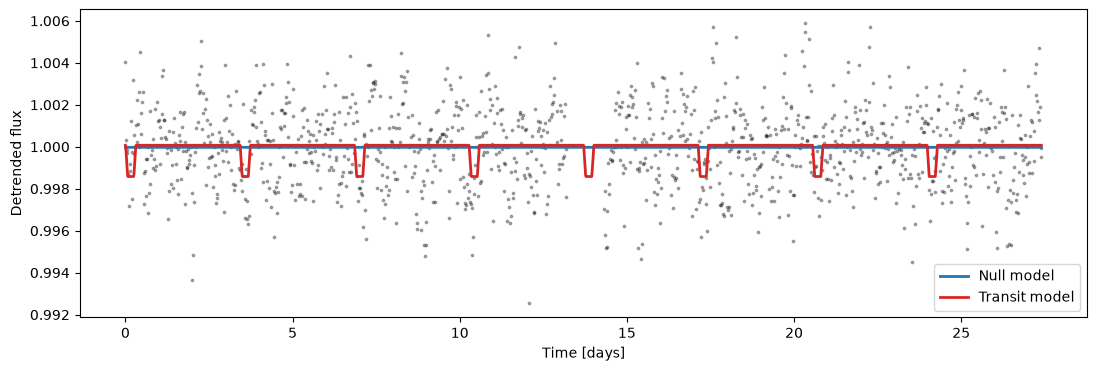

In [433]:
def neg2logL_null(theta):
    F0 = theta[0]
    resid = flux_detrended - F0
    return np.sum(resid**2 / sigma_detrended**2 + np.log(sigma_detrended**2))

null_fit = minimize(neg2logL_null, x0=[np.median(flux_detrended)], method='Nelder-Mead')

transit_n2ll = neg2logL(res.x)
null_n2ll = null_fit.fun

print(f"Null model F0 = {null_fit.x[0]:.8f}")
print(f"Null -2 ln L = {null_n2ll:.6f}")
print(f"Transit -2 ln L = {transit_n2ll:.6f}")
print(f"Delta(-2 ln L) = {null_n2ll - transit_n2ll:.6f}")
t_grid = np.linspace(t.min(), t.max(), 3000)
null_model = np.full_like(t_grid, null_fit.x[0])
transit_model_grid = transit_model(t_grid, *res.x)

plt.figure(figsize=(13,4))
plt.scatter(t, flux_detrended, s=3, alpha=.3, color='black')
plt.plot(t_grid, null_model, color='tab:blue', lw=2, label='Null model')
plt.plot(t_grid, transit_model_grid, color='tab:red', lw=2, label='Transit model')
plt.xlabel("Time [days]")
plt.ylabel("Detrended flux")
plt.legend()
plt.show()


In [ ]:
def fit_null(y):
    def nll(theta):
        F0 = theta[0]
        resid = y - F0
        return np.sum(resid**2 / sigma_detrended**2 + np.log(sigma_detrended**2))
    return minimize(nll, [np.median(y)], method='Nelder-Mead')

def fit_transit_(y):
    def nll(theta):
        model = transit_model(t, *theta)
        resid = y - model
        return np.sum(resid**2 / sigma_detrended**2 + np.log(sigma_detrended**2))
    return minimize(nll, res.x, method='Nelder-Mead', options={'maxiter': 3000})


Observed delta(-2 ln L) = 77.197
Median null-bootstrap delta = 26.294
95th percentile = 64.462
99th percentile = 81.442
Maximum = 110.313
Bootstrap p-value = 0.0160


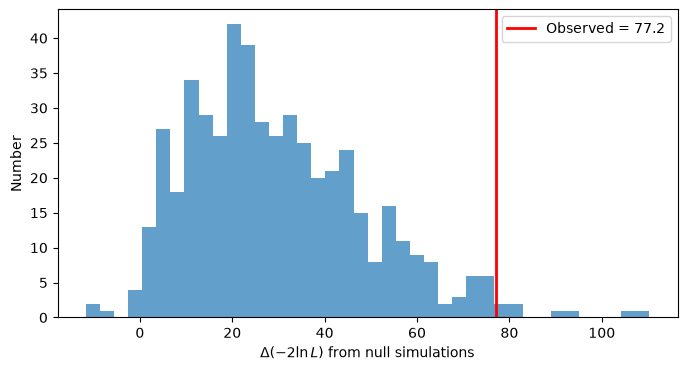

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(null_deltas, bins=40, alpha=.7)
plt.axvline(observed_delta, color='red', lw=2, label=f'Observed = {observed_delta:.1f}')
plt.xlabel(r'$\Delta$neg2 log likelihood from null simulations\n(Simulated data - my data = $\Delta$)')
plt.ylabel('Number')
plt.legend()
plt.show()
